# CosineAnnealingWarmRestartsDecay Visualization

This notebook visualizes our custom learning rate scheduler that combines:
- **Cosine Annealing**: Smooth LR transitions within each cycle
- **Warm Restarts**: Multiple training cycles for better exploration
- **LR Decay**: Reduces max LR after each restart for stability in later phases
- **Smooth Ending**: Distributes remainder epochs to later cycles so training ends at eta_min

This scheduler is designed to align with progressive augmentation, where:
- Early phases (high LR) -> model learns basic features with no/light augmentation
- Later phases (lower LR) -> model fine-tunes with stronger augmentation

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set style for better visualization
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [5]:
class CosineAnnealingWarmRestartsDecay:
    """
    Cosine annealing scheduler with warm restarts and optional LR decay.

    When total_epochs is provided, keeps the same number of cycles (total_epochs // T_0)
    but distributes remainder epochs to later cycles for smooth ending.

    Example: epochs=50, T_0=12 -> 4 cycles with lengths [12, 12, 13, 13]
    """

    def __init__(self, base_lr, T_0, T_mult=1, eta_min=1e-6, decay=1.0, total_epochs=None):
        self.base_lr = base_lr
        self.T_0 = T_0
        self.T_mult = T_mult
        self.eta_min = eta_min
        self.decay = decay
        self.total_epochs = total_epochs
        
        # Pre-compute cycle boundaries
        self._cycle_starts = None
        self._cycle_lengths = None
        self._num_cycles = None
        if total_epochs is not None and T_mult == 1:
            self._compute_cycle_boundaries()
    
    def _compute_cycle_boundaries(self):
        """Compute cycle lengths, distributing remainder to later cycles."""
        num_cycles = self.total_epochs // self.T_0
        if num_cycles == 0:
            num_cycles = 1
        
        remainder = self.total_epochs - (num_cycles * self.T_0)
        
        # Distribute remainder to later cycles
        self._cycle_lengths = []
        for i in range(num_cycles):
            length = self.T_0
            if i >= num_cycles - remainder:
                length += 1
            self._cycle_lengths.append(length)
        
        # Compute start epochs
        self._cycle_starts = [0]
        for i in range(num_cycles - 1):
            self._cycle_starts.append(self._cycle_starts[-1] + self._cycle_lengths[i])
        
        self._num_cycles = num_cycles

    def get_lr(self, epoch):
        """Calculate learning rate for given epoch"""
        # Find cycle info
        if self._cycle_starts is not None:
            for i in range(self._num_cycles - 1, -1, -1):
                if epoch >= self._cycle_starts[i]:
                    cycle = i
                    T_cur = epoch - self._cycle_starts[i]
                    T_i = self._cycle_lengths[i]
                    break
        elif epoch >= self.T_0:
            cycle = epoch // self.T_0
            T_cur = epoch % self.T_0
            T_i = self.T_0
        else:
            cycle = 0
            T_cur = epoch
            T_i = self.T_0

        decay_factor = self.decay ** cycle
        # Use (T_i - 1) so last epoch of each cycle reaches exactly eta_min
        T_denom = max(T_i - 1, 1)
        lr = self.eta_min + (self.base_lr * decay_factor - self.eta_min) * 0.5 * (1 + np.cos(np.pi * T_cur / T_denom))
        return lr, cycle

## 1. The Problem: LR Spike at End of Training

When `epochs` doesn't divide evenly by `T_0`, the scheduler starts a new cycle at the end.

In [ ]:
# Parameters
epochs = 50
base_lr = 1e-4
T_0 = epochs // 4  # = 12
eta_min = 1e-6

print(f"epochs={epochs}, T_0={T_0}")
print(f"Problem: 50 = 12*4 + 2 (2 epochs remainder)")
print(f"Without fix: cycles [12, 12, 12, 12] = 48 epochs, then NEW CYCLE at 48!")

# Old behavior (without total_epochs)
scheduler_old = CosineAnnealingWarmRestartsDecay(base_lr, T_0, decay=0.8, eta_min=eta_min, total_epochs=None)
lrs_old = [scheduler_old.get_lr(e)[0] for e in range(epochs)]

# New behavior (with total_epochs - distributed remainder)
scheduler_new = CosineAnnealingWarmRestartsDecay(base_lr, T_0, decay=0.8, eta_min=eta_min, total_epochs=epochs)
lrs_new = [scheduler_new.get_lr(e)[0] for e in range(epochs)]

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Old behavior
axes[0].plot(range(epochs), lrs_old, 'r-', linewidth=2)
axes[0].axvline(x=48, color='red', linestyle='--', alpha=0.7)
axes[0].annotate('Unwanted spike!', xy=(48, lrs_old[48]), xytext=(38, base_lr*0.7),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Learning Rate', fontsize=12)
axes[0].set_title('WITHOUT total_epochs (Problem)\nCycles: [12, 12, 12, 12] + spike', fontsize=12, color='red')
axes[0].set_xlim(0, epochs)
axes[0].set_ylim(0, base_lr * 1.1)

# New behavior
axes[1].plot(range(epochs), lrs_new, 'g-', linewidth=2)
# Mark cycle boundaries
for start in scheduler_new._cycle_starts[1:]:
    axes[1].axvline(x=start, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title(f'WITH total_epochs (Fixed)\nCycles: {scheduler_new._cycle_lengths}', fontsize=12, color='green')
axes[1].set_xlim(0, epochs)
axes[1].set_ylim(0, base_lr * 1.1)

plt.tight_layout()
plt.show()

print(f"\nOld: LR at epoch 47 = {lrs_old[47]:.2e}, epoch 48 = {lrs_old[48]:.2e} (SPIKE!)")
print(f"New: LR at epoch 48 = {lrs_new[48]:.2e}, epoch 49 = {lrs_new[49]:.2e} (ends at eta_min)")

## 2. How It Works: Distribute Remainder to Later Cycles

Instead of starting a new partial cycle, we make later cycles slightly longer.

In [ ]:
print(f"T_0 = {T_0}, total_epochs = {epochs}")
print(f"\nCalculation:")
print(f"  num_cycles = {epochs} // {T_0} = {epochs // T_0}")
print(f"  remainder = {epochs} - ({epochs // T_0} * {T_0}) = {epochs - (epochs // T_0) * T_0}")
print(f"\nDistribute remainder to LATER cycles:")

scheduler = CosineAnnealingWarmRestartsDecay(base_lr, T_0, decay=0.8, eta_min=eta_min, total_epochs=epochs)
print(f"  Cycle lengths: {scheduler._cycle_lengths}")
print(f"  Cycle starts:  {scheduler._cycle_starts}")
print(f"  Total: {sum(scheduler._cycle_lengths)} epochs")

print(f"\nEach cycle is still a COMPLETE smooth cosine curve!")
print(f"Cycle 0: epochs 0-11  (12 epochs)")
print(f"Cycle 1: epochs 12-23 (12 epochs)")
print(f"Cycle 2: epochs 24-36 (13 epochs) <- +1")
print(f"Cycle 3: epochs 37-49 (13 epochs) <- +1")

## 3. Decay Comparison: decay=1.0 vs decay=0.8

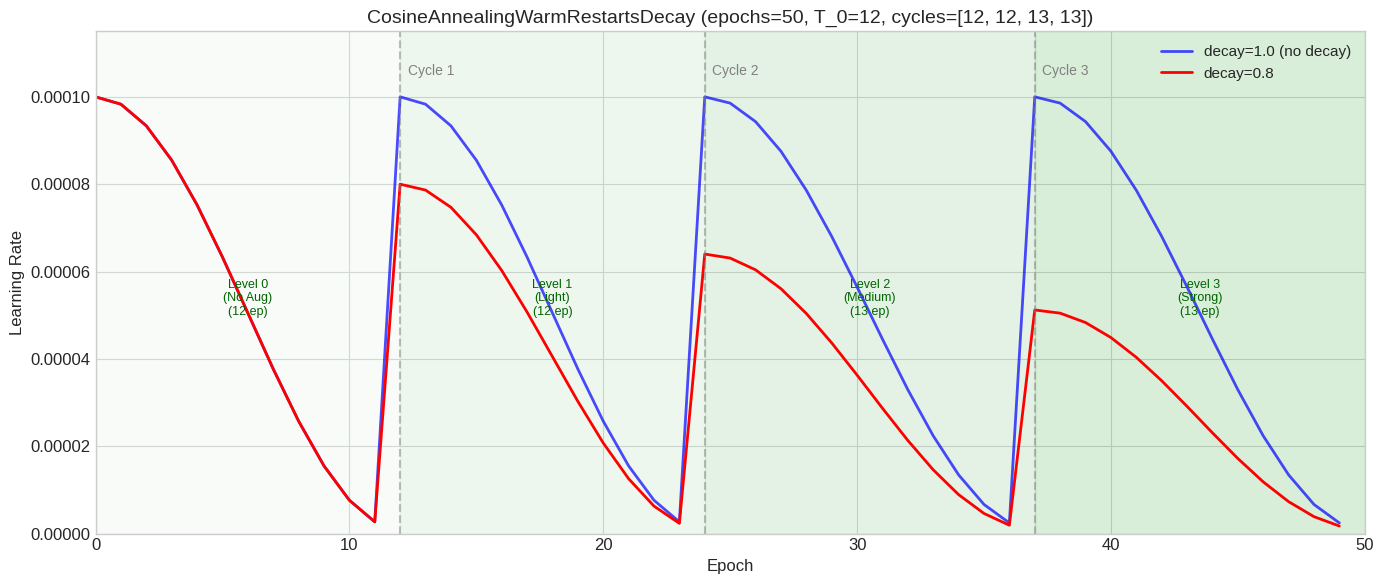

In [8]:
scheduler_no_decay = CosineAnnealingWarmRestartsDecay(base_lr, T_0, decay=1.0, eta_min=eta_min, total_epochs=epochs)
scheduler_decay = CosineAnnealingWarmRestartsDecay(base_lr, T_0, decay=0.8, eta_min=eta_min, total_epochs=epochs)

lrs_no_decay = [scheduler_no_decay.get_lr(e)[0] for e in range(epochs)]
lrs_decay = [scheduler_decay.get_lr(e)[0] for e in range(epochs)]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(epochs), lrs_no_decay, 'b-', linewidth=2, label='decay=1.0 (no decay)', alpha=0.7)
ax.plot(range(epochs), lrs_decay, 'r-', linewidth=2, label='decay=0.8')

# Add cycle boundaries and annotations
cycle_starts = scheduler_decay._cycle_starts
cycle_lengths = scheduler_decay._cycle_lengths
aug_colors = ['#e8f5e9', '#c8e6c9', '#a5d6a7', '#81c784']
aug_labels = ['Level 0\n(No Aug)', 'Level 1\n(Light)', 'Level 2\n(Medium)', 'Level 3\n(Strong)']

for i, (start, length) in enumerate(zip(cycle_starts, cycle_lengths)):
    end = start + length
    ax.axvspan(start, end, alpha=0.3, color=aug_colors[i])
    ax.text(start + length/2, base_lr * 0.5, f'{aug_labels[i]}\n({length} ep)', ha='center', fontsize=9, color='darkgreen')
    if i > 0:
        ax.axvline(x=start, color='gray', linestyle='--', alpha=0.5)
        ax.text(start + 0.3, base_lr * 1.05, f'Cycle {i}', fontsize=10, color='gray')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title(f'CosineAnnealingWarmRestartsDecay (epochs={epochs}, T_0={T_0}, cycles={cycle_lengths})', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(0, epochs)
ax.set_ylim(0, base_lr * 1.15)

plt.tight_layout()
plt.show()

## 4. Different Decay Values

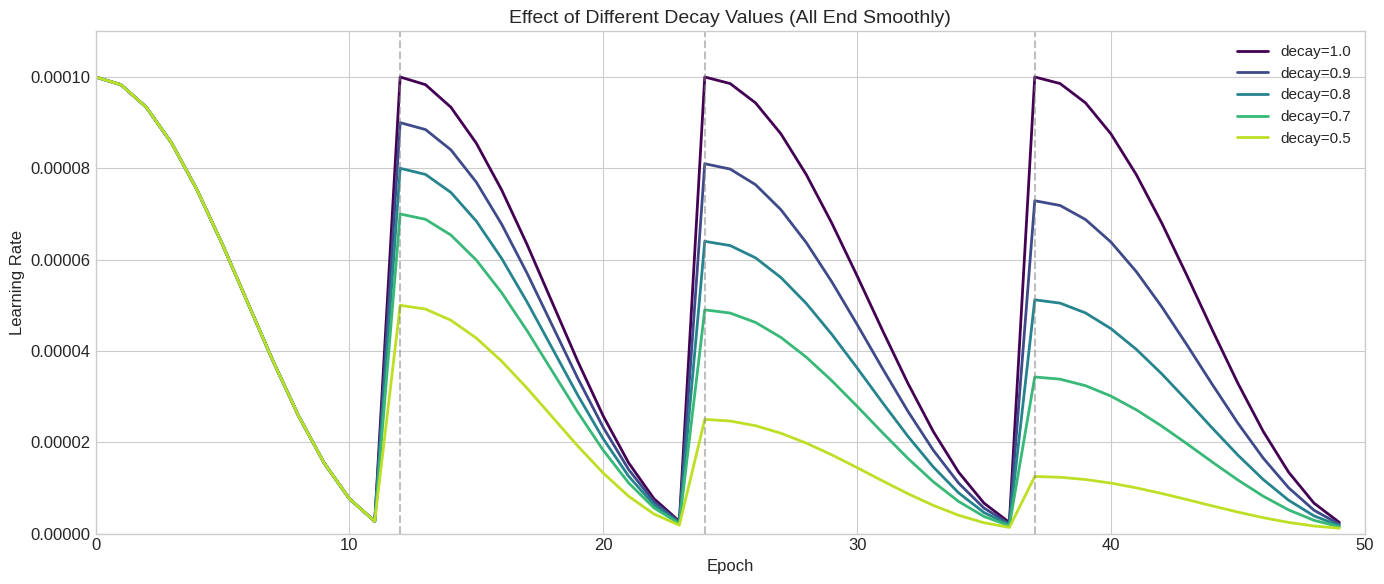

In [9]:
decay_values = [1.0, 0.9, 0.8, 0.7, 0.5]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(decay_values)))

fig, ax = plt.subplots(figsize=(14, 6))

for decay, color in zip(decay_values, colors):
    scheduler = CosineAnnealingWarmRestartsDecay(base_lr, T_0, decay=decay, eta_min=eta_min, total_epochs=epochs)
    lrs = [scheduler.get_lr(e)[0] for e in range(epochs)]
    ax.plot(range(epochs), lrs, color=color, linewidth=2, label=f'decay={decay}')

# Add cycle boundaries
for start in scheduler._cycle_starts[1:]:
    ax.axvline(x=start, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Effect of Different Decay Values (All End Smoothly)', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(0, epochs)
ax.set_ylim(0, base_lr * 1.1)

plt.tight_layout()
plt.show()

## 5. Works with Any Epoch Count

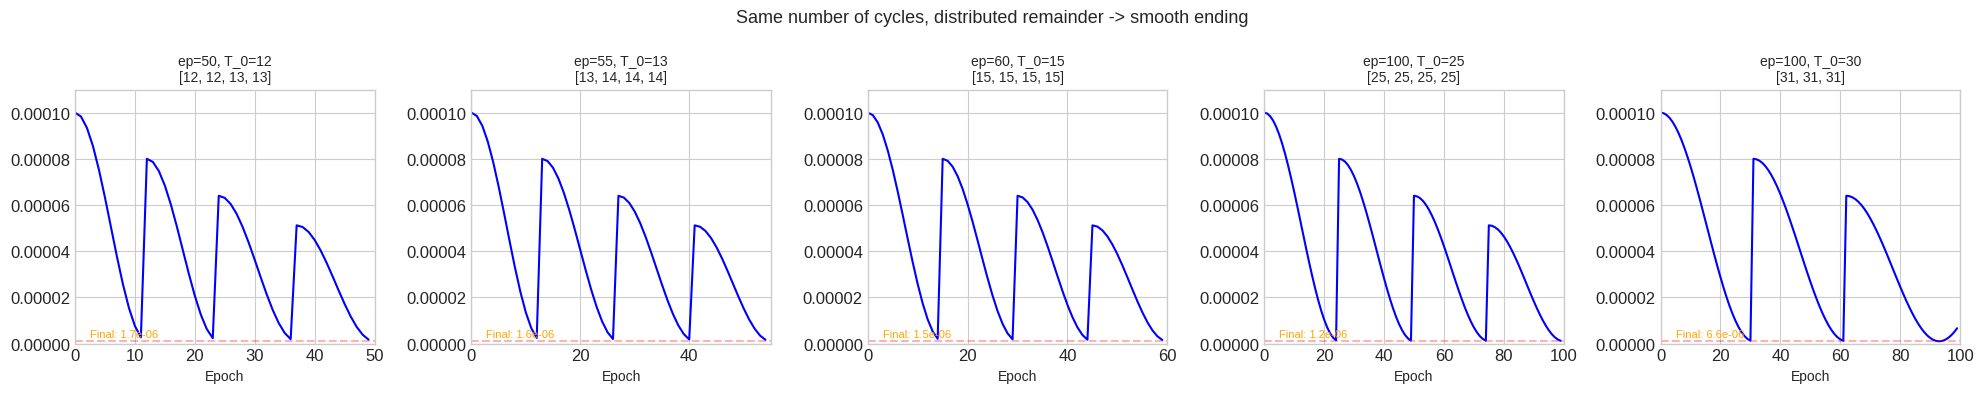

In [10]:
# Test with different epoch counts - all end smoothly!
test_cases = [
    (50, 12),   # 50 = 12*4 + 2 -> [12,12,13,13]
    (55, 13),   # 55 = 13*4 + 3 -> [13,13,14,14] (one gets +1, other +2? no, distribute evenly)
    (60, 15),   # 60 = 15*4 + 0 -> [15,15,15,15] perfect fit
    (100, 25),  # 100 = 25*4 + 0 -> [25,25,25,25] perfect fit
    (100, 30),  # 100 = 30*3 + 10 -> [30,35,35] or similar
]

fig, axes = plt.subplots(1, len(test_cases), figsize=(20, 4))

for ax, (ep, t0) in zip(axes, test_cases):
    scheduler = CosineAnnealingWarmRestartsDecay(base_lr, t0, decay=0.8, eta_min=eta_min, total_epochs=ep)
    lrs = [scheduler.get_lr(e)[0] for e in range(ep)]
    
    ax.plot(range(ep), lrs, 'b-', linewidth=1.5)
    ax.set_title(f'ep={ep}, T_0={t0}\n{scheduler._cycle_lengths}', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_xlim(0, ep)
    ax.set_ylim(0, base_lr * 1.1)
    
    # Verify last LR is near eta_min
    last_lr = lrs[-1]
    ax.axhline(y=eta_min, color='r', linestyle='--', alpha=0.3)
    color = 'green' if abs(last_lr - eta_min) < 1e-7 else 'orange'
    ax.text(ep * 0.05, eta_min * 3, f'Final: {last_lr:.1e}', fontsize=8, color=color)

plt.suptitle('Same number of cycles, distributed remainder -> smooth ending', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Max LR Per Cycle

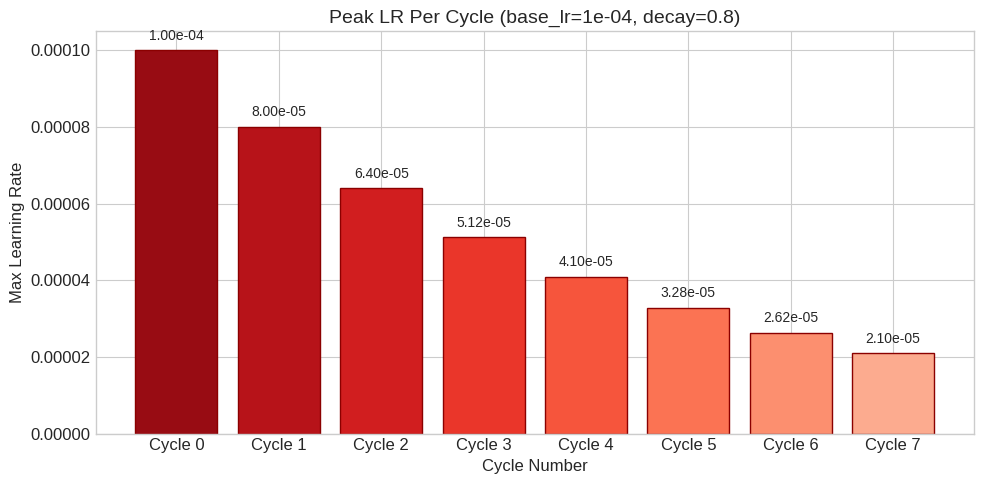

Max LR reduction per cycle:
  Cycle 0: 1.00e-04 (100.0% of base LR)
  Cycle 1: 8.00e-05 (80.0% of base LR)
  Cycle 2: 6.40e-05 (64.0% of base LR)
  Cycle 3: 5.12e-05 (51.2% of base LR)
  Cycle 4: 4.10e-05 (41.0% of base LR)
  Cycle 5: 3.28e-05 (32.8% of base LR)
  Cycle 6: 2.62e-05 (26.2% of base LR)
  Cycle 7: 2.10e-05 (21.0% of base LR)


In [11]:
decay = 0.8
num_cycles_show = 8

max_lrs = [base_lr * (decay ** i) for i in range(num_cycles_show)]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(range(num_cycles_show), max_lrs, color=plt.cm.Reds(np.linspace(0.9, 0.3, num_cycles_show)), edgecolor='darkred')

for i, (bar, lr) in enumerate(zip(bars, max_lrs)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + base_lr*0.02, 
            f'{lr:.2e}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Max Learning Rate', fontsize=12)
ax.set_title(f'Peak LR Per Cycle (base_lr={base_lr:.0e}, decay={decay})', fontsize=14)
ax.set_xticks(range(num_cycles_show))
ax.set_xticklabels([f'Cycle {i}' for i in range(num_cycles_show)])

plt.tight_layout()
plt.show()

print("Max LR reduction per cycle:")
for i, lr in enumerate(max_lrs):
    pct = (lr / base_lr) * 100
    print(f"  Cycle {i}: {lr:.2e} ({pct:.1f}% of base LR)")

## Summary

**CosineAnnealingWarmRestartsDecay** features:

1. **Cosine Annealing**: Smooth LR reduction within each cycle

2. **Warm Restarts**: Multiple exploration phases

3. **Decay Factor**: Reduces max LR after each restart

4. **Smooth Ending**: When `total_epochs` is provided:
   - Keeps same number of cycles: `num_cycles = total_epochs // T_0`
   - Distributes remainder to later cycles
   - Example: 50 epochs, T_0=12 -> cycles [12, 12, 13, 13] instead of [12, 12, 12, 12] + spike
   - Each cycle is still a complete smooth cosine curve
   - Training ends exactly at eta_min

This ensures stable convergence without unexpected LR spikes at the end of training.